In [73]:
import re
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import numpy as np
import sys

DIR = '/Users/ana/Desktop/tns-ana/'

print('Running on computer: ' + DIR)
sys.path.insert(0, DIR + 'main-programs/')

import tns_helpers as helpers

def parse_density_matrix_file(path):
    """
    Parse a density-matrix block structured like your example and return:
      - dm: np.ndarray of shape (Nk, 6, 6), dtype=complex
      - ks: list of (kx, ky) tuples for each k-point
    Assumes each k-point header is like:
      "k-point 0 (kx=-3.14159, ky=-3.14159):"
    and followed by 6 lines, each with 6 entries of the form (a,b).
    """
    header_re = re.compile(r'^k-point\s+(\d+)\s*\(kx=([^,]+),\s*ky=([^)]+)\):')
    tuple_re = re.compile(r'\(\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*,\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*\)')

    ks = []
    blocks = []  # list of 36 (a,b) tuples per k-point

    with open(path, 'r') as f:
        lines = f.readlines()

    i = 0
    N = len(lines)
    while i < N:
        line = lines[i].rstrip('\n')
        m = header_re.match(line)
        if m:
            kidx = int(m.group(1))
            kx = float(m.group(2))
            ky = float(m.group(3))
            ks.append((kx, ky))
            i += 1

            # Collect 36 tuples (6x6) for this k-point
            tuples = []
            while len(tuples) < 36 and i < N:
                line = lines[i]
                for a_str, b_str in tuple_re.findall(line):
                    a = float(a_str)
                    b = float(b_str)
                    tuples.append((a, b))
                i += 1

            if len(tuples) != 36:
                raise ValueError(f"Expected 36 tuples for k-point {kidx}, got {len(tuples)}")

            blocks.append(tuples)
        else:
            i += 1

    Nk = len(blocks)
    if Nk == 0:
        return np.zeros((0, 6, 6), dtype=np.complex128), []

    # Build the density matrix array
    dm = np.zeros((Nk, 6, 6), dtype=np.complex128)

    for k in range(Nk):
        flat = blocks[k]
        for r in range(6):
            for c in range(6):
                a, b = flat[r*6 + c]
                dm[k, r, c] = complex(a, b)

    return dm, ks

# Example usage:
# path = "path/to/your/density_matrix.txt"
# D, ks = parse_density_matrix_file(path)
# print(D.shape)  # should be (Nk, 6, 6)
# print(ks)       # list of (kx, ky) for each k-point

def parse_hamiltonian_file(path):
    """
    Parse the structured text and return a complex array of shape (Nk, 6, 6).

    Returns:
        hs: numpy.ndarray of shape (Nk, 6, 6), dtype=complex
        ks: list of (kx, ky) tuples for each k-point
    """
    # Regular expressions to detect k-point header and a tuple
    header_re = re.compile(r'^k-point\s+(\d+)\s*\(kx=([^,]+),\s*ky=([^)]+)\):')
    tuple_re = re.compile(r'\(\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*,\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*\)')

    ks = []
    blocks = []  # temporary storage for the current 6x6 block of tuples

    with open(path, 'r') as f:
        lines = f.readlines()

    i = 0
    N = len(lines)
    while i < N:
        line = lines[i].rstrip('\n')
        m = header_re.match(line)
        if m:
            # New k-point found
            kidx = int(m.group(1))
            kx = float(m.group(2))
            ky = float(m.group(3))
            ks.append((kx, ky))
            i += 1

            # Read the next 6 lines (or more, some lines may be indented oddly)
            # We'll collect all tuples until we have 36 of them (6x6)
            tuples = []
            while len(tuples) < 36 and i < N:
                line = lines[i]
                for ta, tb in tuple_re.findall(line):
                    a = float(ta)
                    b = float(tb)
                    tuples.append((a, b))
                i += 1

            if len(tuples) != 36:
                raise ValueError(f"Expected 36 tuples for k-point {kidx}, got {len(tuples)}")

            blocks.append(tuples)
        else:
            i += 1

    Nk = len(blocks)
    if Nk == 0:
        return np.zeros((0, 6, 6), dtype=complex), []

    # Build the array
    hs = np.zeros((Nk, 6, 6), dtype=np.complex128)

    for k in range(Nk):
        flat = blocks[k]  # 36 tuples
        # fill row-major: row 0 col 0..5, row 1 col 0..5, ...
        for r in range(6):
            for c in range(6):
                a, b = flat[r*6 + c]
                hs[k, r, c] = complex(a, b)

    return hs, ks

# Example usage:
# path = "path/to/your/input.txt"
# H, ks = parse_hamiltonian_file(path)
# Now H.shape -> (Nk, 6, 6); H[k] is the 6x6 matrix for k-point k
# ks contains the (kx, ky) for each k-point


Running on computer: /Users/ana/Desktop/tns-ana/


In [41]:
Hk, K = parse_hamiltonian_file("hk_iter0.out")
Nx = int(Hk.shape[0]**0.5)
Ny = Nx

Kx = np.zeros(Nx)
Ky = np.zeros(Ny)
for i in range(Nx):
    Kx[i] = K[i*Nx][0]  # kx from the first column of each block
for j in range(Ny):
    Ky[j] = K[j][1]  # ky from the first row of each block

Hk_denis = Hk.reshape((Nx, Ny, 6, 6))
Hk_ana = np.load('hk_ana.npy')

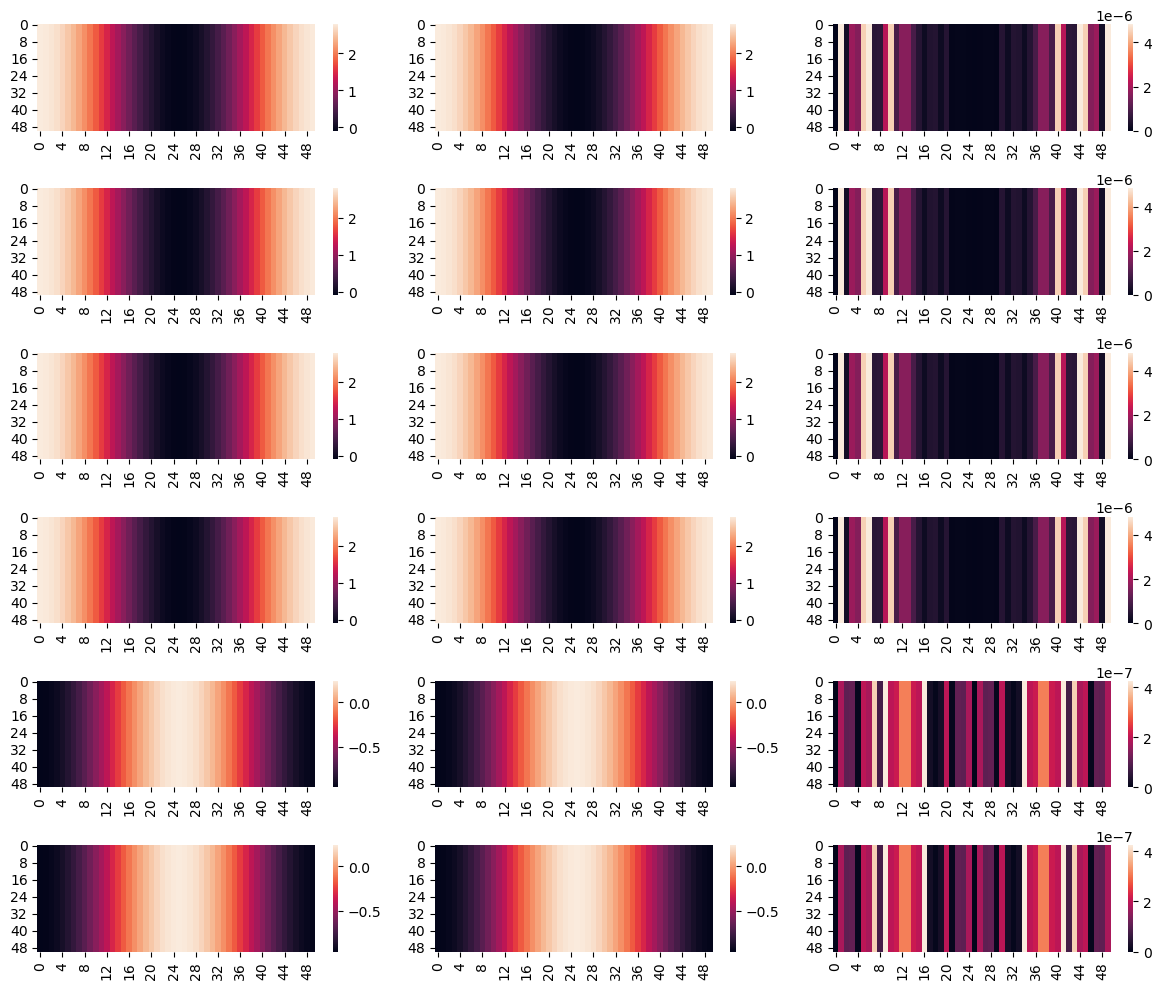

In [42]:
fig, axs = plt.subplots(ncols=3, nrows=6, figsize=(12,10))

for i in range(6):
    sns.heatmap(Hk_denis[:,:,i,i].real, ax=axs[i,0])
    sns.heatmap(Hk_ana[i,i].real, ax=axs[i,1])
    sns.heatmap(np.abs(Hk_denis[:,:,i,i] - Hk_ana[i,i]), ax=axs[i,2])

plt.tight_layout()

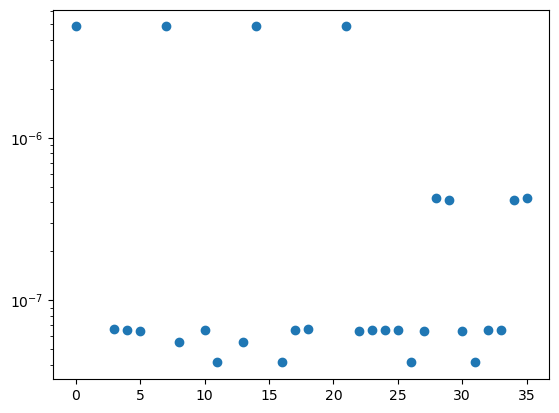

In [48]:
differences = []
for i in range(6):
    for j in range(6):
       differences.append(np.max(np.abs(Hk_denis[:,:,i,j].conj() - Hk_ana[i,j])))

plt.scatter(np.arange(len(differences)), differences)
plt.yscale('log')

<Axes: >

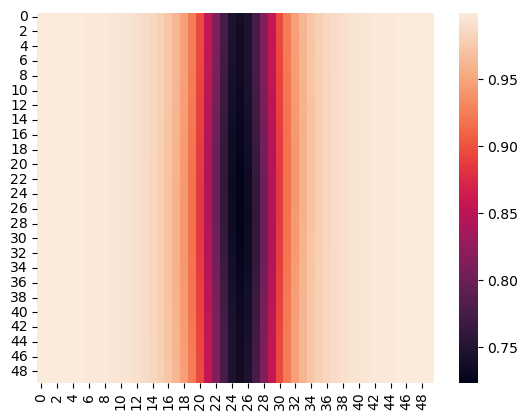

In [64]:
rho0 = parse_density_matrix_file('denk_iter0.out')[0].reshape((Nx, Ny, 6, 6))

sns.heatmap(rho0[:,:,4,4].real)

False

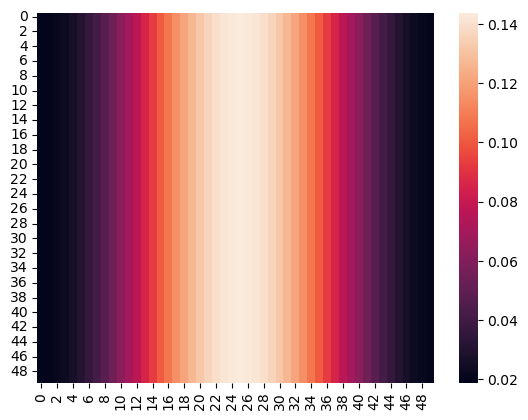

In [71]:
Hfock = parse_hamiltonian_file("fock_iter1.out")[0].reshape((50,50,6,6))
sns.heatmap(Hfock[:,:,0,4].real)
np.allclose(Hfock,0)

In [77]:
import numpy as np

def read_columnar_matrix(path):
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            # first item is the row index
            idx = int(parts[0])
            # remaining numbers are the row elements
            nums = [float(x) for x in parts[1:]]
            rows.append(nums)
    # Verify all rows have same length
    n_cols = len(rows[0])
    for r in rows:
        if len(r) != n_cols:
            raise ValueError("Inconsistent row lengths in file.")
    mat = np.array(rows, dtype=float)  # shape (n_rows, n_cols)
    return mat

# Example usage:
# M = read_columnar_matrix("path/to/file.txt")
# print(M.shape)  # (n_rows, n_cols)


data = read_columnar_matrix('all.out')

data.shape

(5, 31)